In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

from skfda.datasets._samples_generators import make_gaussian_process
from skfda.misc.covariances import Exponential, Gaussian
from skfda.misc.metrics import l2_distance, l2_norm
from skfda.preprocessing.dim_reduction import FPCA

In [6]:
grid_size = 100

cov_clean = Gaussian(variance=2.0, length_scale=5.0)

n_train = 10**3
train_set = make_gaussian_process(
    n_samples=n_train,
    n_features=grid_size,
    start=0.0,
    stop=25.0,
    cov=cov_clean,
    random_state=20
)
train_set_labels = np.array(['train(nonoutliers)'] * n_train)

In [7]:
n_test = 50
test_set_clean = make_gaussian_process(
    n_samples=n_test // 2,
    n_features=grid_size,
    start=0.0,
    stop=25.0,
    cov=cov_clean,
    random_state=20
)  # clean test set
test_set_clean_labels = np.array(['test(nonoutliers)'] * (n_test // 2))

cov_outlier = Exponential()

test_set_outlier = make_gaussian_process(
    n_samples=n_test // 2,
    n_features=grid_size,
    start=0.0,
    stop=25.0,
    cov=cov_outlier,
    random_state=20
)  # test set with outliers
test_set_outlier.sample_names = [
    'test_outl_' + str(i) for i in range(test_set_outlier.n_samples)]
test_set_outlier_labels = np.array(['test(outliers)'] * (n_test // 2))

test_set = test_set_clean.concatenate(test_set_outlier)
test_set_labels = np.concatenate(
    (test_set_clean_labels, test_set_outlier_labels)
)

C:\Users\HYKP\AppData\Local\Temp\ipykernel_25752\303883104.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


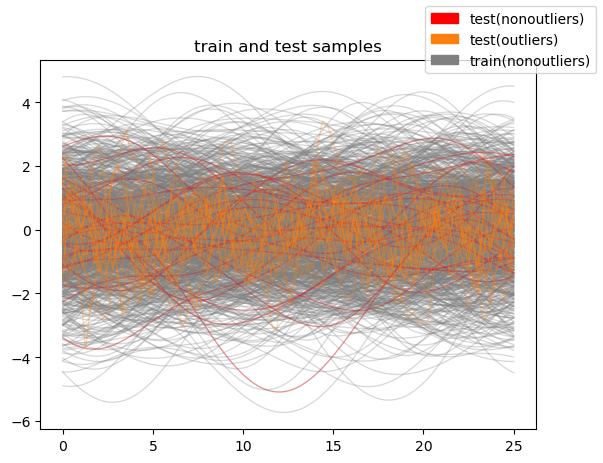

In [8]:
whole_data = train_set.concatenate(test_set)
whole_data_labels = np.concatenate((train_set_labels, test_set_labels))

fig = whole_data.plot(
    group=whole_data_labels,
    group_colors={
        'train(nonoutliers)': 'grey',
        'test(nonoutliers)': 'red',
        'test(outliers)': 'C1'},
    linewidth=0.95,
    alpha=0.3,
    legend=True
)
plt.title('train and test samples')
fig.show()

In [22]:
q = 5
fpca_clean = FPCA(n_components=q)
fpca_clean.fit(train_set)
train_set_hat = fpca_clean.inverse_transform(
    fpca_clean.transform(train_set)
)

err_train = l2_distance(
    train_set,
    train_set_hat
) / l2_norm(train_set)

test_set_hat = fpca_clean.inverse_transform(
    fpca_clean.transform(test_set)
)
err_test = l2_distance(
    test_set,
    test_set_hat
) / l2_norm(test_set)

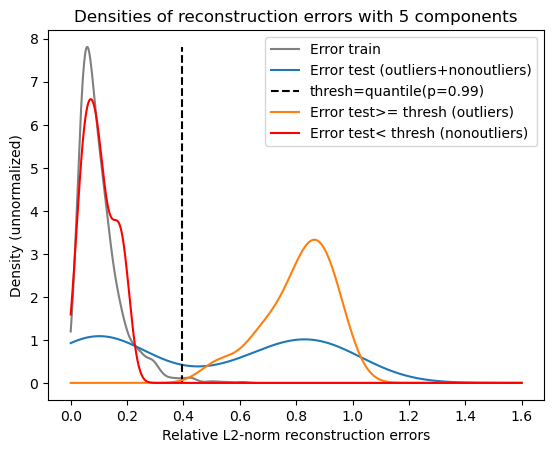

In [23]:
x_density = np.linspace(0., 1.6, num=10**3)
density_train_err = gaussian_kde(err_train)
density_test_err = gaussian_kde(err_test)
err_thresh = np.quantile(err_train, 0.99)

density_test_err_outl = gaussian_kde(err_test[err_test >= err_thresh])
density_test_err_inli = gaussian_kde(err_test[err_test < err_thresh])

# density estimate of train errors
plt.plot(
    x_density,
    density_train_err(x_density),
    label='Error train',
    color='grey'
)

# density estimate of test errors
plt.plot(
    x_density,
    density_test_err(x_density),
    label='Error test (outliers+nonoutliers)',
    color='C0'
)

# outlyingness threshold
plt.vlines(
    err_thresh,
    ymax=max(density_train_err(x_density)),
    ymin=0.0,
    label='thresh=quantile(p=0.99)',
    linestyles='dashed',
    color='black'
)

# density estimate of the error of test samples flagged as outliers
plt.plot(
    x_density,
    density_test_err_outl(x_density),
    label='Error test>= thresh (outliers)',
    color='C1'
)

# density estimate of the error of test samples flagged as nonoutliers
plt.plot(
    x_density,
    density_test_err_inli(x_density),
    label='Error test< thresh (nonoutliers)',
    color='red'
)

plt.xlabel('Relative L2-norm reconstruction errors')
plt.ylabel('Density (unnormalized)')
plt.title(f'Densities of reconstruction errors with {q} components')
plt.legend()
plt.show()

In [24]:
print('Flagged outliers: ')
print(test_set_labels[err_test >= err_thresh])
print('Flagged nonoutliers: ')
print(test_set_labels[err_test < err_thresh])

Flagged outliers: 
['test(nonoutliers)' 'test(outliers)' 'test(outliers)' 'test(outliers)'
 'test(outliers)' 'test(outliers)' 'test(outliers)' 'test(outliers)'
 'test(outliers)' 'test(outliers)' 'test(outliers)' 'test(outliers)'
 'test(outliers)' 'test(outliers)' 'test(outliers)' 'test(outliers)'
 'test(outliers)' 'test(outliers)' 'test(outliers)' 'test(outliers)'
 'test(outliers)' 'test(outliers)' 'test(outliers)' 'test(outliers)'
 'test(outliers)' 'test(outliers)']
Flagged nonoutliers: 
['test(nonoutliers)' 'test(nonoutliers)' 'test(nonoutliers)'
 'test(nonoutliers)' 'test(nonoutliers)' 'test(nonoutliers)'
 'test(nonoutliers)' 'test(nonoutliers)' 'test(nonoutliers)'
 'test(nonoutliers)' 'test(nonoutliers)' 'test(nonoutliers)'
 'test(nonoutliers)' 'test(nonoutliers)' 'test(nonoutliers)'
 'test(nonoutliers)' 'test(nonoutliers)' 'test(nonoutliers)'
 'test(nonoutliers)' 'test(nonoutliers)' 'test(nonoutliers)'
 'test(nonoutliers)' 'test(nonoutliers)' 'test(nonoutliers)']


In [2]:
# Author: Yujian Hong
# License: MIT

import matplotlib.pyplot as plt

import skfda
from skfda.datasets import fetch_growth
from skfda.exploratory.visualization import FPCAPlot
from skfda.preprocessing.dim_reduction import FPCA
from skfda.representation.basis import (
    BSplineBasis,
    FourierBasis,
    MonomialBasis,
)

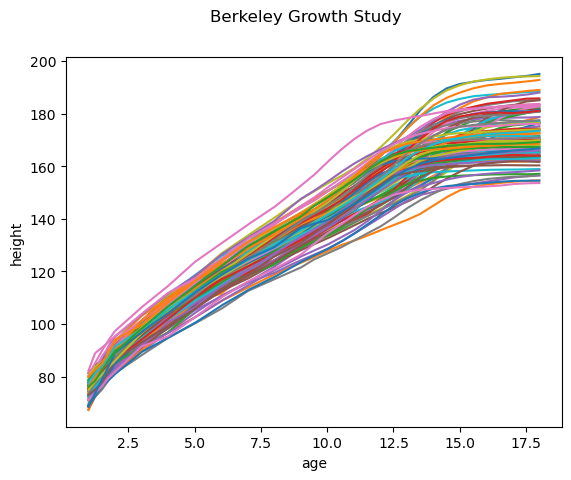

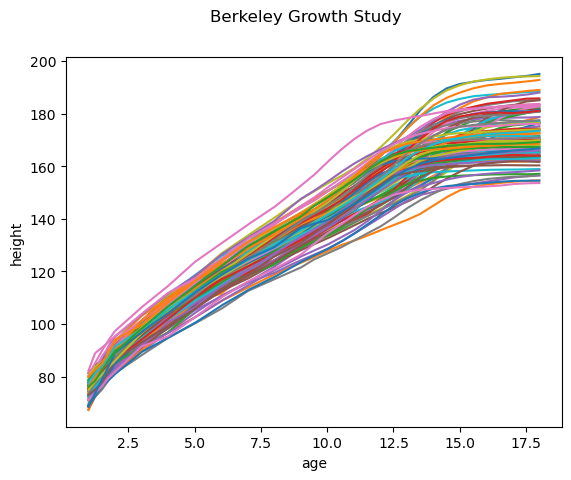

In [3]:
dataset = skfda.datasets.fetch_growth()
fd = dataset['data']
y = dataset['target']
fd.plot()

In [26]:
a = fpca_discretized.components_.data_matrix[0]
b = fpca_discretized.components_.data_matrix[1]

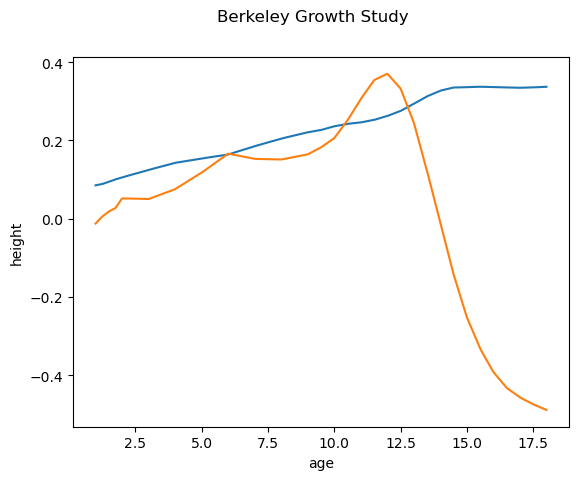

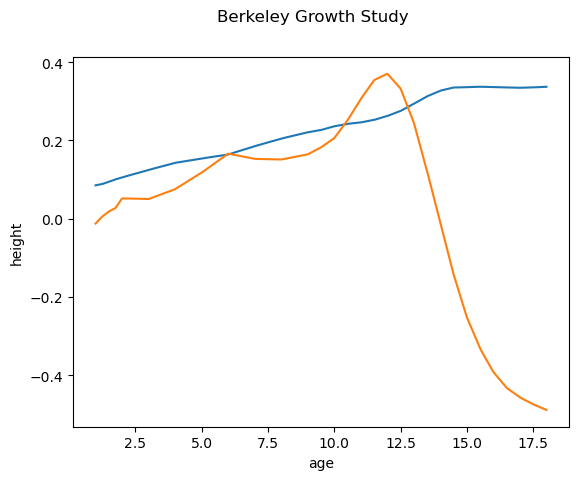

In [5]:
fpca_discretized = FPCA(n_components=2)
fpca_discretized.fit(fd)
fpca_discretized.components_.plot()

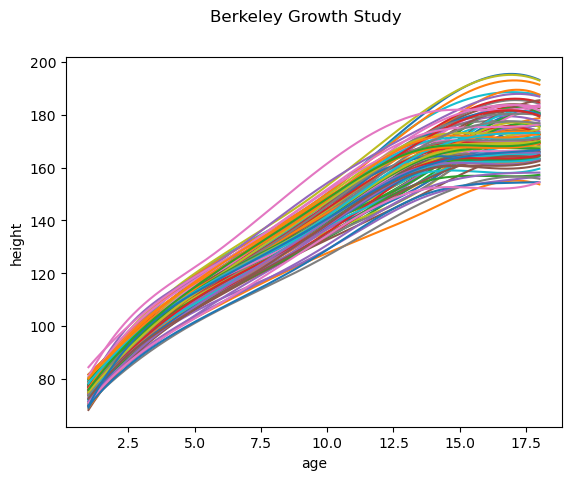

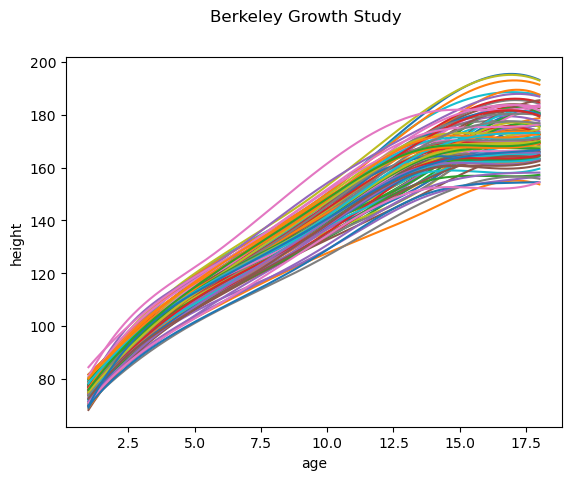

In [32]:
dataset = fetch_growth()
fd = dataset['data']
basis = skfda.representation.basis.BSplineBasis(n_basis=7)
basis_fd = fd.to_basis(basis)
basis_fd.plot()

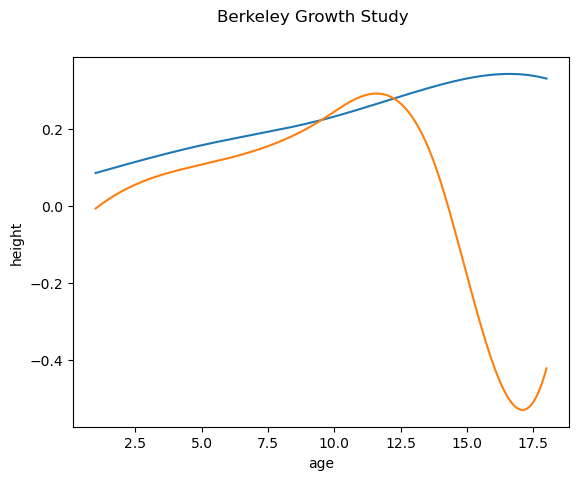

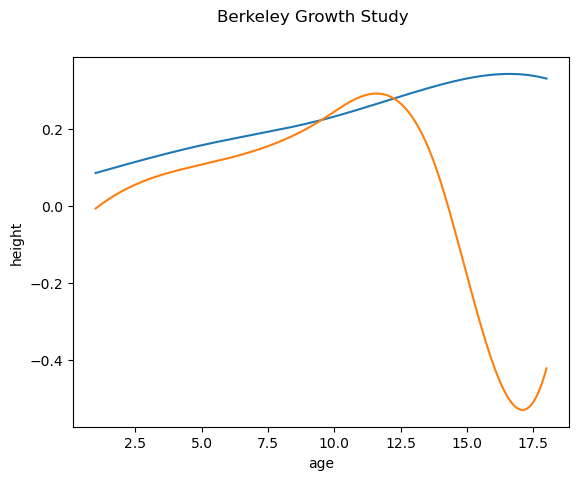

In [33]:
fpca = FPCA(n_components=2)
fpca.fit(basis_fd)
fpca.components_.plot()

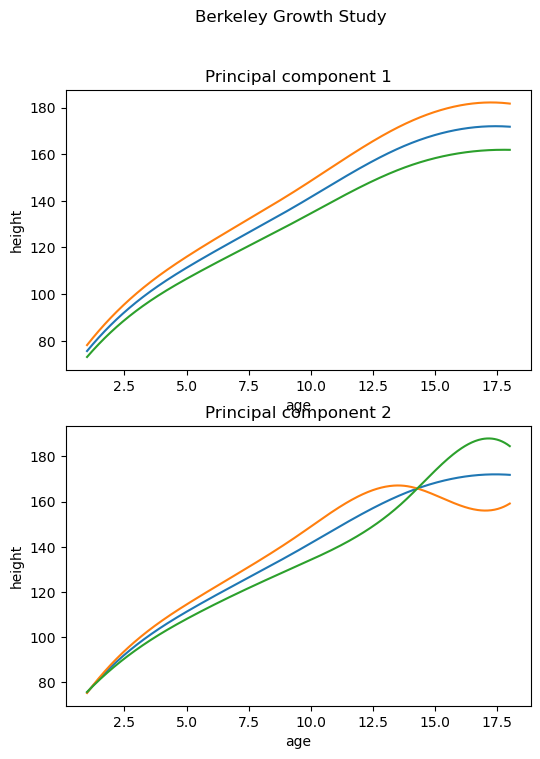

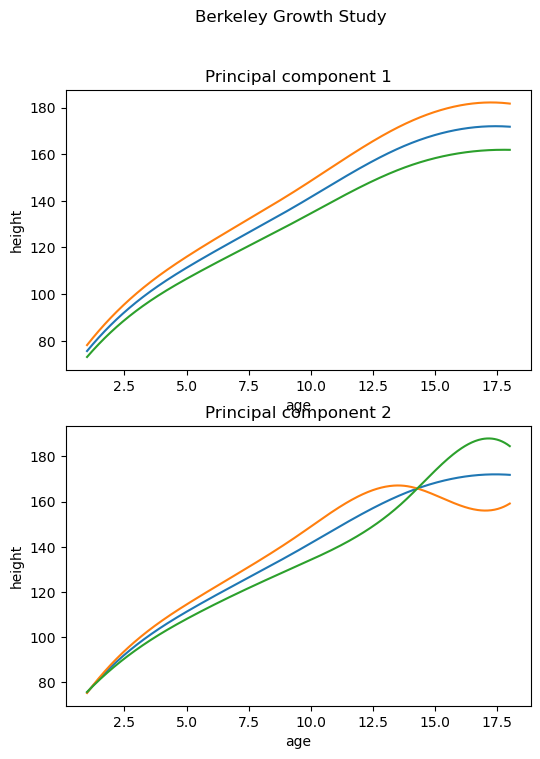

In [34]:
FPCAPlot(
    basis_fd.mean(),
    fpca.components_,
    factor=30,
    fig=plt.figure(figsize=(6, 2 * 4)),
    n_rows=2,
).plot()

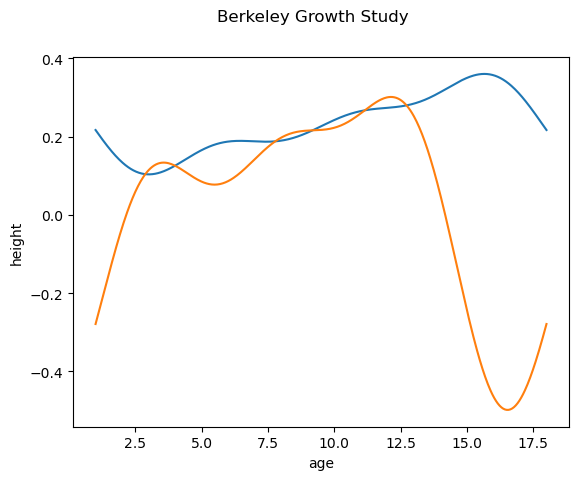

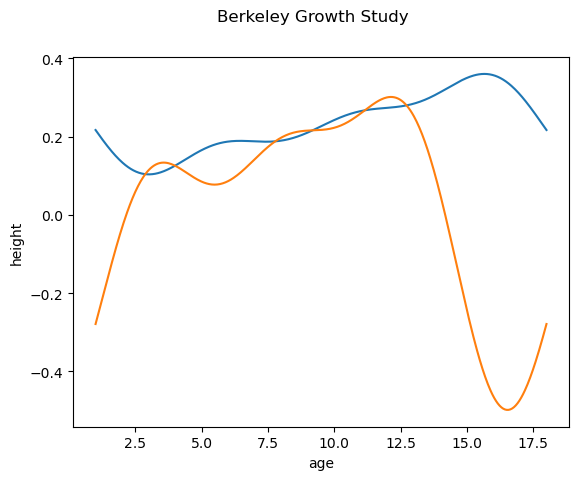

In [35]:
dataset = fetch_growth()
fd = dataset['data']
basis_fd = fd.to_basis(BSplineBasis(n_basis=7))
fpca = FPCA(n_components=2, components_basis=FourierBasis(n_basis=7))
fpca.fit(basis_fd)
fpca.components_.plot()

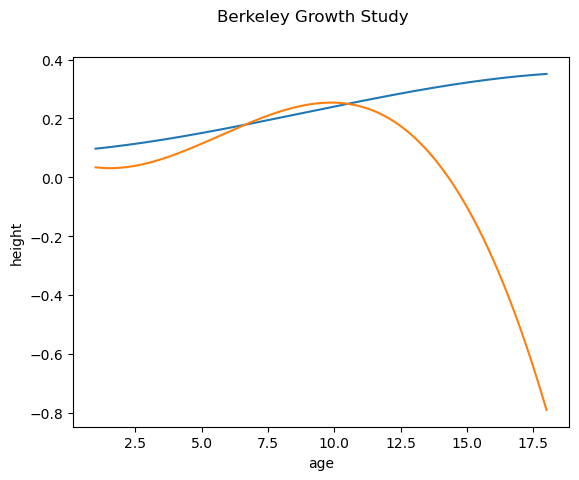

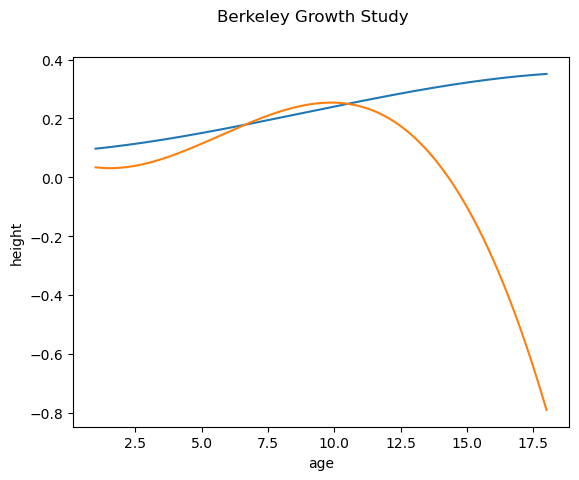

In [36]:
dataset = fetch_growth()
fd = dataset['data']
basis_fd = fd.to_basis(BSplineBasis(n_basis=7))
fpca = FPCA(n_components=2, components_basis=MonomialBasis(n_basis=4))
fpca.fit(basis_fd)
fpca.components_.plot()